# 1. Answer the questions

## 1. Derive an analytical solution to the regression problem. Use a vector form of the equation.

### Веса линейной регрессии (OLS)

Веса линейной регрессии находятся **из принципа минимизации наименьших квадратов** (МНК, ordinary least squares, OLS):

$$L(w) = \sum_{n=1}^N (x_n^T w - y_n)^2 \to \min_w$$


### Тип векторов

Все вектора в этом разделе, как и глобально в книге, будем считать **векторами-столбцами** (а не строками).

---

## Градиент и условие минимума

Достаточным условием минимума потерь будет покомпонентное равенство нулю **градиента** функции потерь. Причем, также в силу  
выпуклости функции, будет гарантия, что найденный минимум будет **глобальным** минимумом функционала, т.е. обеспечивать наименьшее значение функции потерь среди всех возможных.

Мы говорим про **градиент**, а не про производную, поскольку при дифференцировании  
скалярной функции
$L(w) \in \mathbb{R}$
по вектору
 $w \in \mathbb{R}^{D+1}$ получим вектор частных  
производных по каждой компоненте вектора $w$:

$$\nabla L(w) =
\begin{pmatrix}
\frac{\partial L}{\partial w_0} \\
\frac{\partial L}{\partial w_1} \\
\frac{\partial L}{\partial w_2} \\
\vdots \\
\frac{\partial L}{\partial w_D}
\end{pmatrix}$$

---

## Аналитическое решение

Найдем оптимальные веса аналитически. Достаточным условием минимума потерь будет покомпонентное равенство нулю **градиента** функции потерь.

$$\nabla L(\hat{w}) = 2 \sum_{n=1}^N x_n \left( x_n^T \hat{w} - y_n \right) = 0$$

$$\left( \sum_{n=1}^N x_n x_n^T \right) \hat{w} = \sum_{n=1}^N x_n y_n$$

Перепишем условие, используя обозначения для матрицы объекты-признаки $X \in \mathbb{R}^{N \times D}$ и вектора откликов $Y \in \mathbb{R}^N$:

$$X^T X \hat{w} = X^T Y$$

Откуда получаем аналитическое итоговое решение для линейной регрессии:

$$\hat{w} = (X^T X)^{-1} X^T Y$$

## 2. What changes in the solution when L1 and L2 regularizations are added to the loss function.

Как известно, слишком простые (то есть недостаточно гибкие по выразительной способности) модели строят неточные прогнозы из-за недообучения, а слишком сложные (избыточно гибкие) - к неточным прогнозам из-за переобучения, что можно проиллюстрировать характерным графиком:

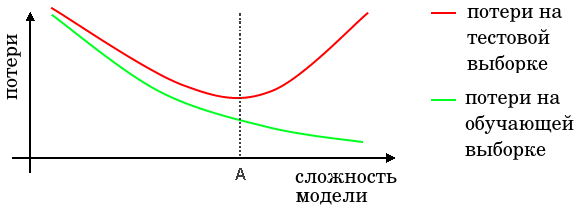

Поэтому важно подобрать сложность модели таким образом, чтобы её сложность соответствовала сложности реальных данных (точка A на графике выше).

В связи с этими недостатками принято контролировать сложность модели, добавляя в её настройку дополнительное слагаемое (регуляризатор) $R(w)$:

$$L(w|X, Y) = \frac{1}{N} \sum_{n=1}^{N} (x_n^T w - y_n)^2 + \lambda R(w) \to \min_w$$

Конкретный вид для линейной регрессии с MSE

Где:
- $L$ (функция потерь) = $(x_n^T w - y_n)^2$ — это квадрат ошибки
- $f(x_i, \theta) = x_n^T w$ — линейное предсказание

## 3. Explain why L1 regularization is often used to select features. Why are there many weights equal to 0 after the model is fit?

L1-регуляризация (часто называемая регрессией Lasso) используется для отбора признаков, потому что добавляет к функции потерь штраф, пропорциональный абсолютному значению коэффициентов, что заставляет менее важные веса признаков обнуляться .Устраняя эти особенности, L1 создает разреженную модель, что упрощает модель, делает ее более интерпретируемой и предотвращает переобучение, игнорируя шум.

Штраф L1 больше для весов в интервале (-1,1), чем штраф L2, поэтому регуляризация L1 более агрессивно уменьшает веса в этих режимах.



$$R(\mathbf{w}) = \|\mathbf{w}\|_1 = \sum_{d=0}^D |w_d|, \quad \text{вариант: } R(\mathbf{w}) = \sum_{d=1}^D |w_d|$$

Такие большие штрафы связаны с модулем

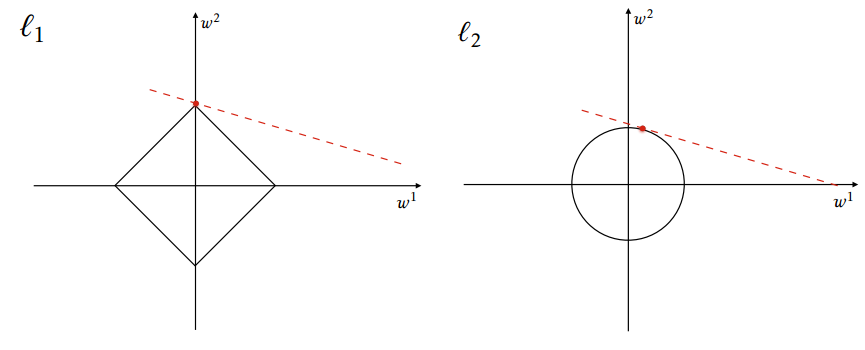

L1-регуляризация добавляет ограничение в виде ромба:

$$\min_{\theta} \|X\theta - y\|_2^2 \quad \text{при } \|\theta\|_1 \leq t$$

Углы ромба (при $\lambda > 0$) располагаются на осях координат, что способствует обнулению коэффициентов.

## 4. Explain how you can use the same models (Linear regression, Ridge, etc.) but make it possible to fit nonlinear dependencies.



Линейная модель $y = \theta_0 + \theta_1 x$ не может уловить нелинейность. Но мы можем **расширить пространство признаков**, добавив нелинейные преобразования исходных переменных.

**Пример с полиномиальными признаками:** Вместо модели с одним признаком $x$:

$$y = \theta_0 + \theta_1 x$$

Мы создаем новые признаки: $x, x^2, x^3, \dots$ и получаем модель:

$$y = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \dots$$

**Важно:** модель остается **линейной относительно параметров $\theta$, но становится нелинейной относительно исходной переменной $x$!**

Можно создавать различные полиномальные признаки, используя функции синуса, логарифма и т.д.

# 2. Introduction — make all the preprocessing staff from the previous lesson

### 1. Import libraries.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import lightgbm
#import scipy
#import statsmodels.api as sm
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

### 2. Read Train and Test Parts.

In [4]:
df = pd.read_json('data/train.json')
#test = pd.read_json('data/test.json')

In [5]:
#print('Размер тестовой выборки')
#print(f'Кол-во строк: {test.shape[0]}')
#print(f'Кол-во столбцов: {test.shape[1]}')

In [6]:
print('Размер датасета')
print(f'Кол-во строк: {df.shape[0]}')
print(f'Кол-во столбцов: {df.shape[1]}')

Размер датасета
Кол-во строк: 49352
Кол-во столбцов: 15


In [7]:
df_orig= df.copy()

In [8]:
df['interest_level'].value_counts()

interest_level
low       34284
medium    11229
high       3839
Name: count, dtype: int64

In [9]:
encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
df['interest_level'] = encoder.fit_transform(df[['interest_level']])

In [10]:
df['interest_level'].value_counts()

interest_level
0.0    34284
1.0    11229
2.0     3839
Name: count, dtype: int64

In [11]:
lower = df['price'].quantile(0.01)  # 1 перцентиль
upper = df['price'].quantile(0.99)  # 99 перцентиль
print(f'Было до удаления выбросов {len(df)} строк')

df = df[(df['price'] >= lower) & (df['price'] <= upper)]
print(f'\nСтало после удаления выбросов {len(df)} строк')

Было до удаления выбросов 49352 строк

Стало после удаления выбросов 48379 строк


In [12]:
#print(f'Было до удаления выбросов {len(test)} строк')

#test = test[(test['price'] >= lower) & (test['price'] <= upper)]
#print(f'\nСтало после удаления выбросов {len(test)} строк')

<Axes: >

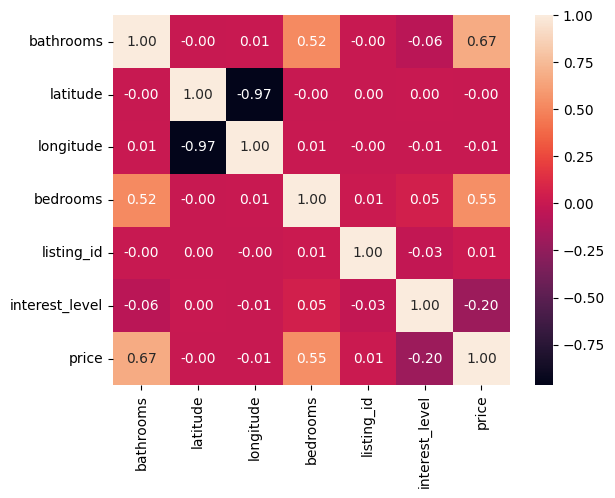

In [13]:
numeric_cols = ['bathrooms', 'latitude', 'longitude', 'bedrooms', 'listing_id', 'interest_level', 'price']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='rocket')

# 3. Intro data analysis part 2

### 1. Let's generate additional features for better model quality. Consider a column called "Features". It consists of a list of highlights of the current flat.

### 2. Remove unused symbols ([,], ', ", and space) from the column.

In [14]:
df['features'].head()

4     [Dining Room, Pre-War, Laundry in Building, Di...
6     [Doorman, Elevator, Laundry in Building, Dishw...
9     [Doorman, Elevator, Laundry in Building, Laund...
10                                                   []
15    [Doorman, Elevator, Fitness Center, Laundry in...
Name: features, dtype: object

In [15]:
import re
df['features_clean'] = df['features'].apply(
    lambda feats: [re.sub(r"[\[\]\'\"\s]", "", str(f)) for f in feats]
)

In [16]:
#test['features_clean'] = test['features'].apply(
#    lambda feats: [re.sub(r"[\[\]\'\"\s]", "", str(f)) for f in feats]
#)

In [17]:
df[['features_clean', 'features']].head()

,features_clean,features
4,"[DiningRoom, Pre-War, LaundryinBuilding, Dishw...","[Dining Room, Pre-War, Laundry in Building, Di..."
6,"[Doorman, Elevator, LaundryinBuilding, Dishwas...","[Doorman, Elevator, Laundry in Building, Dishw..."
9,"[Doorman, Elevator, LaundryinBuilding, Laundry...","[Doorman, Elevator, Laundry in Building, Laund..."
10,[],[]
15,"[Doorman, Elevator, FitnessCenter, LaundryinBu...","[Doorman, Elevator, Fitness Center, Laundry in..."


### 3. Get all values in each list and collect the result in one huge list for the whole dataset. You can use DataFrame.iterrows().

In [18]:
features_list = []

for index, row in df.iterrows():
    features_list.extend(row['features_clean'])

### 4. How many unique values does a result list contain?

In [19]:
unique_count = len(set(features_list))
print("Уникальных значений:", unique_count)

Уникальных значений: 1528


### 5. Let's get acquainted with the new library — Collections. With this package you could effectively get quantity statistics about your data.

In [20]:
from collections import Counter

### 6. Count the most popular functions from our huge list and take the top 20 for this moment.

In [21]:
function_counts = Counter(features_list)
top_20 = function_counts.most_common(20)

for function, count in top_20:
    print(f"{function}: {count}")

Elevator: 25398
HardwoodFloors: 23159
CatsAllowed: 23148
DogsAllowed: 21662
Doorman: 20497
Dishwasher: 20095
NoFee: 17806
LaundryinBuilding: 16093
FitnessCenter: 13000
Pre-War: 8978
LaundryinUnit: 8448
RoofDeck: 6423
OutdoorSpace: 5137
DiningRoom: 4901
HighSpeedInternet: 4225
Balcony: 2898
SwimmingPool: 2648
LaundryInBuilding: 2565
NewConstruction: 2507
Terrace: 2179


### 7. If everything is correct, you should get next values:  'Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

### 8. Now create 20 new features based on the top 20 values: 1 if the value is in the "Feature" column, otherwise 0.

In [22]:
X = df[['bathrooms', 'bedrooms']]
for feat, count in top_20:
    col_name = f"feat_{feat}"
    X[col_name] = df['features_clean'].apply(lambda lst: int(feat in set(lst))) # Если есть feat в lst, int = 1, иначе 0.

In [23]:
#X_test = test[['bathrooms', 'bedrooms']]
#for feat, count in top_20:
#    col_name = f"feat_{feat}"
#    X_test[col_name] = test['features_clean'].apply(lambda lst: int(feat in set(lst))) # Если есть feat в lst, int = 1, иначе 0.

### 9. Extend our feature set with 'bathrooms', 'bedrooms' and create a special variable feature_list with all feature names. Now we have 22 values. All models should be trained on these 22 features.

In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   bathrooms               48379 non-null  float64
 1   bedrooms                48379 non-null  int64  
 2   feat_Elevator           48379 non-null  int64  
 3   feat_HardwoodFloors     48379 non-null  int64  
 4   feat_CatsAllowed        48379 non-null  int64  
 5   feat_DogsAllowed        48379 non-null  int64  
 6   feat_Doorman            48379 non-null  int64  
 7   feat_Dishwasher         48379 non-null  int64  
 8   feat_NoFee              48379 non-null  int64  
 9   feat_LaundryinBuilding  48379 non-null  int64  
 10  feat_FitnessCenter      48379 non-null  int64  
 11  feat_Pre-War            48379 non-null  int64  
 12  feat_LaundryinUnit      48379 non-null  int64  
 13  feat_RoofDeck           48379 non-null  int64  
 14  feat_OutdoorSpace       48379 non-null  in

# 4. Models implementation — Linear regression

### 1. Implement a Python class for a linear regression algorithm with two basic methods — fit and predict. Use stochastic gradient descent (SGD) to find optimal model weights. For better understanding, we recommend implementing separate versions of the algorithm with the analytical solution and non-stochastic gradient descent under the hood.

In [25]:
class CustomLinearRegression:
  """
  Кастомная реализация линейной регрессии.
  Поддерживает:
  - SGD (стохастический градиентный спуск)
  - Batch GD (пакетный градиентный спуск)
  - Аналитическое решение (через псевдообратную матрицу)
  """
  def __init__(self, fit_intercept=True):
    self.fit_intercept = fit_intercept # Добавлять ли смещение в модель
    self.coef_ = None

  def _prepare_X(self, X):
    X_arr = np.asarray(X, dtype=float) # Преобразование матрицы признаков в массив
    if self.fit_intercept:
        ones = np.ones((X_arr.shape[0], 1), dtype=float) # Создаём столбец из единиц размером (n_samples, 1)
        X_arr = np.hstack([ones, X_arr]) # # Объединяем столбец единиц с исходными признаками по горизонтали
    return X_arr

  def fit(self, X, y, lr=1e-5, n_epochs=30, random_state=42):
    return self.fit_sgd(X, y, lr=lr, n_epochs=n_epochs, random_state=random_state)

  def fit_sgd(self, X, y, lr=1e-5, n_epochs=30, random_state=42): # сделали сгд детерменированным
    Xp = self._prepare_X(X) # Делаем из признаков вектор
    yp = np.asarray(y, dtype=float)
    n_samples, n_features = Xp.shape

    self.coef_ = np.zeros(n_features, dtype=float)
    rng = np.random.default_rng(random_state) # Создаём генератор случайных чисел с заданным зерном

    for _ in range(n_epochs):
      indices = rng.permutation(n_samples) # Перемешиваем индексы объектов (важно для SGD)
      for i in indices:
        xi = Xp[i]
        yi = yp[i]
        # Вычисляем ошибку: предсказание минус истинное значение
        # Предсказание: xi @ self.coef_ = сумма(xi_j * w_j)
        error = xi @ self.coef_ - yi
        grad = 2.0 * error * xi # Высчитываем градиент (производная) (направление увеличения ошибки)
        self.coef_ -= lr * grad  # Делаем шаг в сторону уменьшения ошибки
    return self

  def fit_analytic(self, X, y):
    """
    Обучение модели с помощью аналитического решения (через псевдообратную матрицу).
    Этот метод:
    - Находит ТОЧНОЕ решение (не приближённое, как градиентный спуск)
    - Работает быстро для небольших данных
    - Не требует настройки скорости обучения и количества эпох
    """
    Xp = self._prepare_X(X)
    yp = np.asarray(y, dtype=float)
    self.coef_ = np.linalg.pinv(Xp) @ yp
    return self

  def fit_gd(self, X, y, lr=1e-5, n_iter=5000):
    """
    В отличие от SGD, здесь градиент вычисляется на ВСЕХ объектах сразу,
    и веса обновляются один раз за итерацию.
    """
    Xp = self._prepare_X(X)
    yp = np.asarray(y, dtype=float)
    n_samples, n_features = Xp.shape

    self.coef_ = np.zeros(n_features, dtype=float)
    for _ in range(n_iter):
      y_pred = Xp @ self.coef_
      grad = (2.0 / n_samples) * (Xp.T @ (y_pred - yp)) # Делим на N, чтобы градиент не зависел от размера выборки
      self.coef_ -= lr * grad

    return self

  def predict(self, X):
    Xp = self._prepare_X(X)
    return Xp @ self.coef_

### 2. What is determenistic model? Make SGD determenistic.

Детерминированная модель - модель, в которой один и тот же входной сигнал всегда приводит к совершенно одинаковому выходному результату, без случайности или неопределенности.

Я сделала SGD детерминированным благодаря n_samples в permutation и random seed.

### 3. Define the R squared (R2) coefficient and implement a function to calculate it.

In [26]:
def r2_custom(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ss_res = np.sum((y_true - y_pred) ** 2) # Sum of squared residuals
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return 0.0

    return 1.0 - ss_res / ss_tot

In [27]:
def mae_custom(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

In [28]:
def rmse_custom(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

### 4. Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.

In [29]:
y = df['price'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (38703, 22)
X_test : (9676, 22)
y_train: (38703,)
y_test : (9676,)


In [30]:
model_sgd = CustomLinearRegression()
model_sgd.fit(X_train, y_train, lr=1e-5, n_epochs=30, random_state=42)

train_pred = model_sgd.predict(X_train)
test_pred = model_sgd.predict(X_test)

In [31]:
y_train_pred_custom = model_sgd.predict(X_train)
y_test_pred_custom = model_sgd.predict(X_test)

In [32]:
custom_metrics = {
    'model': ['CustomLinear_SGD_det'],
    'train_mae': [mae_custom(y_train, y_train_pred_custom)],
    'test_mae': [mae_custom(y_test, y_test_pred_custom)],
    'train_rmse': [rmse_custom(y_train, y_train_pred_custom)],
    'test_rmse': [rmse_custom(y_test, y_test_pred_custom)],
    'train_r2': [r2_custom(y_train, y_train_pred_custom)],
    'test_r2': [r2_custom(y_test, y_test_pred_custom)],
}

custom_metrics_df = pd.DataFrame(custom_metrics)
custom_metrics_df

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,CustomLinear_SGD_det,711.407708,713.909503,1034.883927,1042.361939,0.581243,0.570919


### 5. Initialize LinearRegression() from sklearn.linear_model, fit the model, and predict the training and test parts as in the previous lesson.

In [33]:
sk_linreg = LinearRegression()
sk_linreg.fit(X_train, y_train)

LinearRegression()

In [34]:
y_train_pred_sk = sk_linreg.predict(X_train)
y_test_pred_sk = sk_linreg.predict(X_test)

### 6. Compare the quality metrics and make sure the difference is small (between your implementations and sklearn).

In [35]:
sk_metrics = {
    'model': ['Sklearn_LinearRegression'],
    'train_mae': [mae_custom(y_train, y_train_pred_sk)],
    'test_mae': [mae_custom(y_test, y_test_pred_sk)],
    'train_rmse': [rmse_custom(y_train, y_train_pred_sk)],
    'test_rmse': [rmse_custom(y_test, y_test_pred_sk)],
    'train_r2': [r2_custom(y_train, y_train_pred_sk)],
    'test_r2': [r2_custom(y_test, y_test_pred_sk)],
}

sk_metrics_df = pd.DataFrame(sk_metrics)

In [36]:
comparison_df = pd.concat([custom_metrics_df, sk_metrics_df], ignore_index=True)
display(comparison_df)

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,CustomLinear_SGD_det,711.407708,713.909503,1034.883927,1042.361939,0.581243,0.570919
1,Sklearn_LinearRegression,711.052088,713.744657,1033.914020,1041.535616,0.582028,0.571599


### 7. Store the metrics as in the previous lesson in a table with columns model, train, test for MAE table, RMSE table, and R2 coefficient.

In [37]:
def to_metric_table(df_metrics, metric_name):
    return pd.DataFrame({
        'model': df_metrics['model'].values,
        'train': df_metrics[f'train_{metric_name}'].values,
        'test': df_metrics[f'test_{metric_name}'].values,
    })

mae_table = to_metric_table(comparison_df, 'mae')
rmse_table = to_metric_table(comparison_df, 'rmse')
r2_table = to_metric_table(comparison_df, 'r2')

In [38]:
print('MAE table')
display(mae_table)

MAE table


,model,train,test
0,CustomLinear_SGD_det,711.407708,713.909503
1,Sklearn_LinearRegression,711.052088,713.744657


In [39]:
print('RMSE table')
display(rmse_table)

RMSE table


,model,train,test
0,CustomLinear_SGD_det,1034.883927,1042.361939
1,Sklearn_LinearRegression,1033.914020,1041.535616


In [40]:
print('R2 table')
display(r2_table)

R2 table


,model,train,test
0,CustomLinear_SGD_det,0.581243,0.570919
1,Sklearn_LinearRegression,0.582028,0.571599


# 5. Regularized models implementation — Ridge, Lasso, ElasticNet

### 1. Implement Ridge, Lasso, ElasticNet algorithms: extend the loss function with L2, L1 and both regularizations accordingly.

In [41]:
class CustomRegularizedLinearRegression:
    def __init__(self, penalty='ridge', alpha=1.0, l1_ratio=0.5, fit_intercept=True):
        self.penalty = penalty
        self.alpha = alpha # Сила регуляции
        self.l1_ratio = l1_ratio # для ElasticNet: пропорция L1 (0 = только L2, 1 = только L1)
        self.fit_intercept = fit_intercept
        self.coef_ = None

    def _prepare_X(self, X):
        X_arr = np.asarray(X, dtype=float)
        if self.fit_intercept:
            ones = np.ones((X_arr.shape[0], 1), dtype=float)
            X_arr = np.hstack([ones, X_arr])
        return X_arr

    def _reg_grad(self, w):

        reg_grad = np.zeros_like(w) # Массив для хранения градиентов регуляризации
        w_no_bias = w[1:] # Bias не регуляризируется

        if self.penalty == 'ridge':
            # Все эл-ты массива, начиная со второго
            reg_grad[1:] = 2.0 * self.alpha * w_no_bias # Производная нашего штрафа
        elif self.penalty == 'lasso':
            reg_grad[1:] = self.alpha * np.sign(w_no_bias)
        elif self.penalty == 'elasticnet':
            l1 = self.l1_ratio
            l2 = 1.0 - self.l1_ratio
            reg_grad[1:] = self.alpha * (l1 * np.sign(w_no_bias) + 2.0 * l2 * w_no_bias)
        else:
            raise ValueError("penalty must be 'ridge', 'lasso', or 'elasticnet'")

        return reg_grad

    def fit(self, X, y, lr=1e-4, n_epochs=40, random_state=42):
        Xp = self._prepare_X(X)
        yp = np.asarray(y, dtype=float)
        n_samples, n_features = Xp.shape

        self.coef_ = np.zeros(n_features, dtype=float)
        rng = np.random.default_rng(random_state)

        for _ in range(n_epochs):
          # Типа градиент но на 2 переменные его разбиваем, чтобы сначала градиент, а потом прибавить штраф
            indices = rng.permutation(n_samples)
            for i in indices:
                xi = Xp[i]
                yi = yp[i]
                err = xi @ self.coef_ - yi
                data_grad = 2.0 * err * xi
                grad = data_grad + self._reg_grad(self.coef_)
                self.coef_ -= lr * grad

        return self

    def predict(self, X):
        Xp = self._prepare_X(X)
        return Xp @ self.coef_

### 2. Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.

In [42]:
alpha_ridge = 1.0
alpha_lasso = 1.0
alpha_enet = 1.0
l1_ratio_enet = 0.5

# Для Ridge уменьшаем шаг и увеличиваем эпохи: L2-штраф чувствителен к lr
custom_ridge = CustomRegularizedLinearRegression(penalty='ridge', alpha=alpha_ridge).fit(
    X_train, y_train, lr=1e-5, n_epochs=500, random_state=42
)
custom_lasso = CustomRegularizedLinearRegression(penalty='lasso', alpha=alpha_lasso).fit(
    X_train, y_train, lr=1e-4, n_epochs=40, random_state=42
)
custom_enet = CustomRegularizedLinearRegression(
    penalty='elasticnet', alpha=alpha_enet, l1_ratio=l1_ratio_enet
).fit(X_train, y_train, lr=2e-4, n_epochs=40, random_state=42)

In [43]:
ridge_train_pred = custom_ridge.predict(X_train)
ridge_test_pred = custom_ridge.predict(X_test)

lasso_train_pred = custom_lasso.predict(X_train)
lasso_test_pred = custom_lasso.predict(X_test)

enet_train_pred = custom_enet.predict(X_train)
enet_test_pred = custom_enet.predict(X_test)

In [44]:
ridge_metrics = {
    'model': ['Ridge_Custom_LinearRegression'],
    'train_mae': [mae_custom(y_train, ridge_train_pred)],
    'test_mae': [mae_custom(y_test, ridge_test_pred)],
    'train_rmse': [rmse_custom(y_train, ridge_train_pred)],
    'test_rmse': [rmse_custom(y_test, ridge_test_pred)],
    'train_r2': [r2_custom(y_train, ridge_train_pred)],
    'test_r2': [r2_custom(y_test, ridge_test_pred)],
}

lasso_metrics = {
    'model': ['Lasso_Custom_LinearRegression'],
    'train_mae': [mae_custom(y_train, lasso_train_pred)],
    'test_mae': [mae_custom(y_test, lasso_test_pred)],
    'train_rmse': [rmse_custom(y_train, lasso_train_pred)],
    'test_rmse': [rmse_custom(y_test, lasso_test_pred)],
    'train_r2': [r2_custom(y_train, lasso_train_pred)],
    'test_r2': [r2_custom(y_test, lasso_test_pred)],
}

enet_metrics = {
    'model': ['Enet_Custom_LinearRegression'],
    'train_mae': [mae_custom(y_train, enet_train_pred)],
    'test_mae': [mae_custom(y_test, enet_test_pred)],
    'train_rmse': [rmse_custom(y_train, enet_train_pred)],
    'test_rmse': [rmse_custom(y_test, enet_test_pred)],
    'train_r2': [r2_custom(y_train, enet_train_pred)],
    'test_r2': [r2_custom(y_test, enet_test_pred)],
}

In [45]:
df_ridge = pd.DataFrame(ridge_metrics)
df_lasso = pd.DataFrame(lasso_metrics)
df_enet = pd.DataFrame(enet_metrics)

custom_reg_res = pd.concat([df_ridge, df_lasso, df_enet], ignore_index=True)
custom_reg_res

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Ridge_Custom_LinearRegression,866.587004,870.877847,1267.760343,1266.520932,0.371576,0.366528
1,Lasso_Custom_LinearRegression,714.093147,716.596439,1034.289119,1041.535066,0.581725,0.571599
2,Enet_Custom_LinearRegression,804.408853,808.966139,1196.106527,1197.168473,0.440606,0.434004


### 3. Initialize Ridge(), Lasso(), and ElasticNet() from sklearn.linear_model, fit the model, and make predictions for the training and test samples as in the previous lesson.

In [46]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X_train, y_train)

ElasticNet(alpha=0.1)

In [47]:
ridge_train_pred = ridge.predict(X_train)
ridge_test_pred = ridge.predict(X_test)

lasso_train_pred = lasso.predict(X_train)
lasso_test_pred = lasso.predict(X_test)

enet_train_pred = elastic_net.predict(X_train)
enet_test_pred = elastic_net.predict(X_test)

In [48]:
ridge_metrics = {
    'model': ['Ridge_LinearRegression'],
    'train_mae': [mae_custom(y_train, ridge_train_pred)],
    'test_mae': [mae_custom(y_test, ridge_test_pred)],
    'train_rmse': [rmse_custom(y_train, ridge_train_pred)],
    'test_rmse': [rmse_custom(y_test, ridge_test_pred)],
    'train_r2': [r2_custom(y_train, ridge_train_pred)],
    'test_r2': [r2_custom(y_test, ridge_test_pred)],
}

lasso_metrics = {
    'model': ['Lasso_LinearRegression'],
    'train_mae': [mae_custom(y_train, lasso_train_pred)],
    'test_mae': [mae_custom(y_test, lasso_test_pred)],
    'train_rmse': [rmse_custom(y_train, lasso_train_pred)],
    'test_rmse': [rmse_custom(y_test, lasso_test_pred)],
    'train_r2': [r2_custom(y_train, lasso_train_pred)],
    'test_r2': [r2_custom(y_test, lasso_test_pred)],
}

enet_metrics = {
    'model': ['Enet_LinearRegression'],
    'train_mae': [mae_custom(y_train, enet_train_pred)],
    'test_mae': [mae_custom(y_test, enet_test_pred)],
    'train_rmse': [rmse_custom(y_train, enet_train_pred)],
    'test_rmse': [rmse_custom(y_test, enet_test_pred)],
    'train_r2': [r2_custom(y_train, enet_train_pred)],
    'test_r2': [r2_custom(y_test, enet_test_pred)],
}

### 4. Compare quality metrics and make sure the difference is small (between your implementations and sklearn).

In [49]:
df_ridge = pd.DataFrame(ridge_metrics)
df_lasso = pd.DataFrame(lasso_metrics)
df_enet = pd.DataFrame(enet_metrics)

reg_res = pd.concat([df_ridge, df_lasso, df_enet], ignore_index=True)
reg_res

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Ridge_LinearRegression,711.048090,713.738979,1033.914028,1041.535006,0.582028,0.571599
1,Lasso_LinearRegression,710.988653,713.683153,1033.916004,1041.537200,0.582026,0.571597
2,Enet_LinearRegression,716.009394,717.454346,1048.213717,1054.698998,0.570386,0.560702


In [50]:
custom_reg_res

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Ridge_Custom_LinearRegression,866.587004,870.877847,1267.760343,1266.520932,0.371576,0.366528
1,Lasso_Custom_LinearRegression,714.093147,716.596439,1034.289119,1041.535066,0.581725,0.571599
2,Enet_Custom_LinearRegression,804.408853,808.966139,1196.106527,1197.168473,0.440606,0.434004


### 5. Store the metrics as in the previous lesson in a table with columns model, train, test for MAE table, RMSE table, and R2 coefficient.

In [51]:
reg_mae_table = to_metric_table(reg_res, 'mae')
reg_rmse_table = to_metric_table(reg_res, 'rmse')
reg_r2_table = to_metric_table(reg_res, 'r2')

In [52]:
reg_mae_table

,model,train,test
0,Ridge_LinearRegression,711.048090,713.738979
1,Lasso_LinearRegression,710.988653,713.683153
2,Enet_LinearRegression,716.009394,717.454346


In [53]:
reg_rmse_table

,model,train,test
0,Ridge_LinearRegression,1033.914028,1041.535006
1,Lasso_LinearRegression,1033.916004,1041.537200
2,Enet_LinearRegression,1048.213717,1054.698998


In [54]:
reg_r2_table

,model,train,test
0,Ridge_LinearRegression,0.582028,0.571599
1,Lasso_LinearRegression,0.582026,0.571597
2,Enet_LinearRegression,0.570386,0.560702


# 6. Feature normalization

### 1. First, write several examples of why and where feature normalization is mandatory and vice versa.

Нормализация данных — это процесс приведения признаков (фичей) к единому масштабу (обычно от 0 до 1 или стандартизация к среднему 0 и отклонению 1). Без этого алгоритмы машинного обучения могут работать неправильно, так как признаки с большими числовыми значениями будут ошибочно считаться более важными.

**Где регуляризация обязательна?**

1. Градиентные методы
Если признаки имеют разные масштабы (например, возраст 0–100 и доход 0–1 000 000), то веса при больших признаках будут меняться очень маленькими шагами, а при маленьких — огромными. Градиентный спуск будет «метаться» и долго сходиться.

2. Регуляризация
Регуляризация штрафует веса всех признаков одинаково. Если признаки в разных масштабах, то веса маленьких признаков придётся сделать огромными, чтобы они влияли на предсказание, и регуляризация их убьёт.

**Пример:** Прогнозирование цены квартиры на основе площади (50–150
) и количества комнат (1–5). Признак «площадь» будет подавлять «комнаты» при расчетах.

**Пример:** При поиске похожих клиентов (KNN), разница в 100 000 рублей дохода (большой масштаб) затмит разницу в 5 лет возраста (маленький масштаб), даже если возраст важнее.

Когда нормализация обычно не обязательна:

- Деревья решений, Random Forest, Gradient Boosting по деревьям: разбиения по порогам слабо зависят от линейного масштаба признаков.
- Если признаки уже в сопоставимых единицах и модель не чувствительна к расстояниям/градиенту.

### 2. Let's consider the first of the classical normalization methods — MinMaxScaler. Write a mathematical formula for this method.

MinMaxScaler — это метод предварительной обработки данных в машинном обучении, который линейно масштабирует признаки в заданный диапазон, обычно [0,1].

$$X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$$

### 3. Implement your own function or class for MinMaxScaler feature normalization.

In [55]:
def MinMaxScalerCustom(X):
  data_min = np.min(X, axis=0)
  data_max = np.max(X, axis=0)
  return (X - data_min) / (data_max - data_min)

### 4. Initialize MinMaxScaler() from sklearn.preprocessing.

In [56]:
sk_minmax_scaler = MinMaxScaler()

### 5. Compare the feature normalization with your own method and with sklearn.

In [57]:
X_train_scaled_custom = MinMaxScalerCustom(X_train)
X_train_scaled_sk = sk_minmax_scaler.fit_transform(X_train)

In [58]:
X_train_scaled_custom.head()

,bathrooms,bedrooms,feat_Elevator,feat_HardwoodFloors,feat_CatsAllowed,feat_DogsAllowed,feat_Doorman,feat_Dishwasher,feat_NoFee,feat_LaundryinBuilding,...,feat_LaundryinUnit,feat_RoofDeck,feat_OutdoorSpace,feat_DiningRoom,feat_HighSpeedInternet,feat_Balcony,feat_SwimmingPool,feat_LaundryInBuilding,feat_NewConstruction,feat_Terrace
51562,0.1,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59592,0.1,0.375,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8687,0.1,0.250,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39366,0.1,0.125,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
92766,0.1,0.250,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
X_train_scaled_sk

array([[0.1  , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.1  , 0.375, 1.   , ..., 0.   , 0.   , 0.   ],
       [0.1  , 0.25 , 1.   , ..., 0.   , 0.   , 0.   ],
       ...,
       [0.1  , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.1  , 0.125, 0.   , ..., 0.   , 0.   , 0.   ],
       [0.1  , 0.   , 1.   , ..., 1.   , 0.   , 1.   ]])

### 6. Repeat the steps from b to e for another normalization method StandardScaler.

**Standardization:**

$$z = \frac{x - \mu}{\sigma}$$

with mean:

$$\mu = \frac{1}{N} \sum_{i=1}^N (x_i)$$

and standard deviation:

$$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2}$$

In [60]:
def StandardScalerCustom(X):
  mean_data = np.mean(X, axis = 0)
  std_data = np.std(X, axis = 0)
  std_data[std_data == 0] = 1
  return (X - mean_data)/ std_data

In [61]:
sk_standard_scaler = StandardScaler()

In [62]:
X_train_scaled_custom_standard = StandardScalerCustom(X_train)
X_train_scaled_sk_standard = sk_standard_scaler.fit_transform(X_train)

In [63]:
X_train_scaled_custom_standard.head()

,bathrooms,bedrooms,feat_Elevator,feat_HardwoodFloors,feat_CatsAllowed,feat_DogsAllowed,feat_Doorman,feat_Dishwasher,feat_NoFee,feat_LaundryinBuilding,...,feat_LaundryinUnit,feat_RoofDeck,feat_OutdoorSpace,feat_DiningRoom,feat_HighSpeedInternet,feat_Balcony,feat_SwimmingPool,feat_LaundryInBuilding,feat_NewConstruction,feat_Terrace
51562,-0.427093,-1.397502,-1.048700,-0.954550,-0.953858,-0.896941,-0.854884,-0.841375,-0.763508,-0.703164,...,-0.459246,-0.389535,-0.343749,-0.335754,-0.307477,-0.251766,-0.240067,-0.236556,-0.233188,-0.217618
59592,-0.427093,1.327401,0.953561,1.047615,1.048374,1.114900,-0.854884,-0.841375,-0.763508,-0.703164,...,-0.459246,-0.389535,-0.343749,-0.335754,-0.307477,-0.251766,-0.240067,-0.236556,-0.233188,-0.217618
8687,-0.427093,0.419100,0.953561,1.047615,1.048374,1.114900,-0.854884,1.188530,-0.763508,-0.703164,...,-0.459246,-0.389535,-0.343749,-0.335754,-0.307477,-0.251766,-0.240067,-0.236556,-0.233188,-0.217618
39366,-0.427093,-0.489201,0.953561,1.047615,1.048374,1.114900,1.169750,1.188530,1.309744,1.422143,...,-0.459246,2.567160,2.909095,-0.335754,3.252280,-0.251766,-0.240067,-0.236556,4.288389,-0.217618
92766,-0.427093,0.419100,-1.048700,-0.954550,1.048374,1.114900,-0.854884,-0.841375,1.309744,-0.703164,...,-0.459246,-0.389535,-0.343749,-0.335754,-0.307477,-0.251766,-0.240067,-0.236556,-0.233188,-0.217618


In [64]:
X_train_scaled_sk_standard

array([[-0.42709339, -1.3975017 , -1.04870021, ..., -0.23655601,
        -0.2331878 , -0.21761768],
       [-0.42709339,  1.32740132,  0.95356136, ..., -0.23655601,
        -0.2331878 , -0.21761768],
       [-0.42709339,  0.41910031,  0.95356136, ..., -0.23655601,
        -0.2331878 , -0.21761768],
       ...,
       [-0.42709339, -1.3975017 , -1.04870021, ..., -0.23655601,
        -0.2331878 , -0.21761768],
       [-0.42709339, -0.48920069, -1.04870021, ..., -0.23655601,
        -0.2331878 , -0.21761768],
       [-0.42709339, -1.3975017 ,  0.95356136, ...,  4.22732861,
        -0.2331878 ,  4.5952149 ]])

# 7. Fit custom and sklearn models with normalized data

In [65]:
X_test_scaled_custom_standard = StandardScalerCustom(X_test)
X_test_scaled_sk_standard = sk_standard_scaler.transform(X_test)

In [66]:
X_test_scaled_custom = MinMaxScalerCustom(X_test)
X_test_scaled_sk = sk_minmax_scaler.transform(X_test)

### 1. Fit all models — Linear Regression, Ridge, Lasso, and ElasticNet — with MinMaxScaler.

In [67]:
def evaluate_metrics_row(model_name, y_tr, pred_tr, y_te, pred_te):
    return {
        'model': model_name,
        'train_mae': mae_custom(y_tr, pred_tr),
        'test_mae': mae_custom(y_te, pred_te),
        'train_rmse': rmse_custom(y_tr, pred_tr),
        'test_rmse': rmse_custom(y_te, pred_te),
        'train_r2': r2_custom(y_tr, pred_tr),
        'test_r2': r2_custom(y_te, pred_te),
    }


def fit_all_models_on_scaled(X_tr_scaled, X_te_scaled, scaler_tag):
    rows = [] # массив, из которого потом будет создаваться датафрейм

    # обучаем кастомные модели
    c_lin = CustomLinearRegression().fit(X_tr_scaled, y_train, lr=1e-5, n_epochs=30, random_state=42)
    c_ridge = CustomRegularizedLinearRegression(penalty='ridge', alpha=alpha_ridge).fit(
        X_tr_scaled, y_train, lr=1e-5, n_epochs=300, random_state=42
    )
    c_lasso = CustomRegularizedLinearRegression(penalty='lasso', alpha=alpha_lasso).fit(
        X_tr_scaled, y_train, lr=1e-4, n_epochs=40, random_state=42
    )
    c_enet = CustomRegularizedLinearRegression(
        penalty='elasticnet', alpha=alpha_enet, l1_ratio=l1_ratio_enet
    ).fit(X_tr_scaled, y_train, lr=1e-4, n_epochs=40, random_state=42)

    # Предсказываем по каждой из моделей
    for name, mdl in [
        ('CustomLinear_SGD_det', c_lin),
        ('Custom_Ridge', c_ridge),
        ('Custom_Lasso', c_lasso),
        ('Custom_ElasticNet', c_enet),
    ]:
        tr_pred = mdl.predict(X_tr_scaled)
        te_pred = mdl.predict(X_te_scaled)
        # Добавляем словарь в массив (новая строчка)
        rows.append(evaluate_metrics_row(f'{name}_{scaler_tag}', y_train, tr_pred, y_test, te_pred))

    # sklearn модели
    s_lin = LinearRegression().fit(X_tr_scaled, y_train)
    s_ridge = Ridge(alpha=alpha_ridge, random_state=42).fit(X_tr_scaled, y_train)
    s_lasso = Lasso(alpha=alpha_lasso, random_state=42, max_iter=10000).fit(X_tr_scaled, y_train)
    s_enet = ElasticNet(alpha=alpha_enet, l1_ratio=l1_ratio_enet, random_state=42, max_iter=10000).fit(X_tr_scaled, y_train)

    for name, mdl in [
        ('Sklearn_LinearRegression', s_lin),
        ('Sklearn_Ridge', s_ridge),
        ('Sklearn_Lasso', s_lasso),
        ('Sklearn_ElasticNet', s_enet),
    ]:
        tr_pred = mdl.predict(X_tr_scaled)
        te_pred = mdl.predict(X_te_scaled)
        rows.append(evaluate_metrics_row(f'{name}_{scaler_tag}', y_train, tr_pred, y_test, te_pred))

    return pd.DataFrame(rows)


In [68]:
minmax_scaled_results_df = fit_all_models_on_scaled(X_train_scaled_sk, X_test_scaled_sk, 'MinMax')
minmax_scaled_results_df

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,CustomLinear_SGD_det_MinMax,875.573863,880.045970,1273.730011,1277.071224,0.365644,0.355931
1,Custom_Ridge_MinMax,1078.985770,1087.534186,1522.506059,1518.728725,0.093649,0.089116
2,Custom_Lasso_MinMax,750.718006,747.479558,1095.501264,1097.938780,0.530750,0.523943
3,Custom_ElasticNet_MinMax,1049.657348,1059.226633,1496.258137,1494.034760,0.124630,0.118497
4,Sklearn_LinearRegression_MinMax,711.052088,713.744657,1033.914020,1041.535616,0.582028,0.571599
5,Sklearn_Ridge_MinMax,711.155835,713.685680,1033.964846,1041.496971,0.581987,0.571631
6,Sklearn_Lasso_MinMax,710.906756,713.411681,1034.337653,1041.817875,0.581685,0.571367
7,Sklearn_ElasticNet_MinMax,1054.833880,1064.461090,1492.293572,1490.303134,0.129263,0.122895


### 2. Fit all models — Linear Regression, Ridge, Lasso, and ElasticNet — with StandardScaler.

In [69]:
standard_scaled_results_df = fit_all_models_on_scaled(X_train_scaled_sk_standard, X_test_scaled_sk_standard, 'Standard')
standard_scaled_results_df

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,CustomLinear_SGD_det_Standard,710.887997,713.447378,1033.955754,1041.365557,0.581994,0.571739
1,Custom_Ridge_Standard,785.968769,792.582925,1139.062530,1145.174719,0.492690,0.482100
2,Custom_Lasso_Standard,711.213796,713.960257,1034.711054,1042.182596,0.581383,0.571066
3,Custom_ElasticNet_Standard,744.926527,749.052262,1086.423062,1093.296968,0.538495,0.527960
4,Sklearn_LinearRegression_Standard,711.052088,713.744657,1033.914020,1041.535616,0.582028,0.571599
5,Sklearn_Ridge_Standard,711.051405,713.743851,1033.914020,1041.535683,0.582028,0.571599
6,Sklearn_Lasso_Standard,710.856237,713.600110,1033.943322,1041.581019,0.582004,0.571561
7,Sklearn_ElasticNet_Standard,740.797992,745.266665,1079.142567,1086.733340,0.544660,0.533611


### 3. Add all results to our dataframe with metrics on samples.

In [70]:
all_metrics_df = pd.concat(
    [comparison_df, custom_reg_res, reg_res, minmax_scaled_results_df, standard_scaled_results_df],
    ignore_index=True
)

display(all_metrics_df)


,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,CustomLinear_SGD_det,711.407708,713.909503,1034.883927,1042.361939,0.581243,0.570919
1,Sklearn_LinearRegression,711.052088,713.744657,1033.914020,1041.535616,0.582028,0.571599
2,Ridge_Custom_LinearRegression,866.587004,870.877847,1267.760343,1266.520932,0.371576,0.366528
3,Lasso_Custom_LinearRegression,714.093147,716.596439,1034.289119,1041.535066,0.581725,0.571599
4,Enet_Custom_LinearRegression,804.408853,808.966139,1196.106527,1197.168473,0.440606,0.434004
5,Ridge_LinearRegression,711.048090,713.738979,1033.914028,1041.535006,0.582028,0.571599
6,Lasso_LinearRegression,710.988653,713.683153,1033.916004,1041.537200,0.582026,0.571597
7,Enet_LinearRegression,716.009394,717.454346,1048.213717,1054.698998,0.570386,0.560702
8,CustomLinear_SGD_det_MinMax,875.573863,880.045970,1273.730011,1277.071224,0.365644,0.355931
9,Custom_Ridge_MinMax,1078.985770,1087.534186,1522.506059,1518.728725,0.093649,0.089116


# 8. Overfit models

### 1. Let's look at an overfitted model in practice. From theory, you know that polynomial regression is easy to overfit. So let's create a toy example and see how regularization works in real life.

### 2. In the previous lesson, we created polynomial features with degree 10. Here we repeat these steps from the previous lesson, remembering that we have only 2 basic features — 'bathrooms' and 'bedrooms'.

In [71]:
X_polinom_train = X_train[['bathrooms', 'bedrooms']].copy()
X_polinom_test =  X_test[['bathrooms', 'bedrooms']].copy()


In [72]:
#print(X_polinom_train.info())
#print(X_polinom_test.info())

In [73]:
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly_train = poly.fit_transform(X_polinom_train)
X_poly_test = poly.transform(X_polinom_test)

In [74]:
poly_scaler = StandardScaler()
X_poly_train_scaled = poly_scaler.fit_transform(X_poly_train)
X_poly_test_scaled = poly_scaler.transform(X_poly_test)

In [75]:
print(f'Обучающая выборка: {X_poly_train_scaled.shape}')
print(f'Тестовая выборка: {X_poly_test_scaled.shape}')

Обучающая выборка: (38703, 65)
Тестовая выборка: (9676, 65)


### 3. And train and fit all our implemented algorithms — Linear Regression, Ridge, Lasso, and ElasticNet — on a set of polynomial features.

In [76]:
poly_custom_rows = []

alpha_poly_ridge = 1.0
alpha_poly_lasso = 0.1
alpha_poly_enet = 0.1
l1_ratio_poly = 0.5

c_lin_poly = CustomLinearRegression().fit(
    X_poly_train_scaled, y_train, lr=1e-4, n_epochs=80, random_state=42
)
c_ridge_poly = CustomRegularizedLinearRegression(penalty='ridge', alpha=alpha_poly_ridge).fit(
    X_poly_train_scaled, y_train, lr=1e-4, n_epochs=80, random_state=42
)
c_lasso_poly = CustomRegularizedLinearRegression(penalty='lasso', alpha=alpha_poly_lasso).fit(
    X_poly_train_scaled, y_train, lr=5e-5, n_epochs=120, random_state=42
)
c_enet_poly = CustomRegularizedLinearRegression(
    penalty='elasticnet', alpha=alpha_poly_enet, l1_ratio=l1_ratio_poly
).fit(X_poly_train_scaled, y_train, lr=5e-5, n_epochs=120, random_state=42)

for name, model in [
    ('CustomLinear_PolyDeg10', c_lin_poly),
    ('CustomRidge_PolyDeg10', c_ridge_poly),
    ('CustomLasso_PolyDeg10', c_lasso_poly),
    ('CustomElasticNet_PolyDeg10', c_enet_poly),
]:
    tr_pred = model.predict(X_poly_train_scaled)
    te_pred = model.predict(X_poly_test_scaled)
    poly_custom_rows.append(evaluate_metrics_row(name, y_train, tr_pred, y_test, te_pred))

In [77]:
poly_sk_rows = []

s_lin_poly = LinearRegression().fit(X_poly_train_scaled, y_train)
s_ridge_poly = Ridge(alpha=alpha_poly_ridge, random_state=42).fit(X_poly_train_scaled, y_train)
s_lasso_poly = Lasso(alpha=alpha_poly_lasso, random_state=42, max_iter=20000).fit(X_poly_train_scaled, y_train)
s_enet_poly = ElasticNet(alpha=alpha_poly_enet, l1_ratio=l1_ratio_poly, random_state=42, max_iter=20000).fit(X_poly_train_scaled, y_train)

for name, model in [
    ('SklearnLinear_PolyDeg10', s_lin_poly),
    ('SklearnRidge_PolyDeg10', s_ridge_poly),
    ('SklearnLasso_PolyDeg10', s_lasso_poly),
    ('SklearnElasticNet_PolyDeg10', s_enet_poly),
]:
    tr_pred = model.predict(X_poly_train_scaled)
    te_pred = model.predict(X_poly_test_scaled)
    poly_sk_rows.append(evaluate_metrics_row(name, y_train, tr_pred, y_test, te_pred))

### 4. Store the results of the quality metrics in the result dataframe.

In [78]:
poly_custom_df = pd.DataFrame(poly_custom_rows)
poly_custom_df

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,CustomLinear_PolyDeg10,2.712053e+201,1.719344e+201,inf,inf,-inf,-inf
1,CustomRidge_PolyDeg10,8.035458e+02,7.953180e+02,2977.432965,1157.977138,-2.46627,0.470456
2,CustomLasso_PolyDeg10,1.256719e+224,8.961529e+223,inf,inf,-inf,-inf
3,CustomElasticNet_PolyDeg10,1.096221e+214,7.817518e+213,inf,inf,-inf,-inf


In [79]:
poly_sk_df = pd.DataFrame(poly_sk_rows)
poly_sk_df

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,SklearnLinear_PolyDeg10,755.578540,3.147196e+07,1075.278407,3.095717e+09,0.547915,-3.784643e+12
1,SklearnRidge_PolyDeg10,759.784697,7.625164e+02,1083.551959,1.092657e+03,0.540931,5.285129e-01
2,SklearnLasso_PolyDeg10,760.512983,7.630481e+02,1085.008914,1.093824e+03,0.539696,5.275052e-01
3,SklearnElasticNet_PolyDeg10,772.334316,7.757072e+02,1103.619138,1.113565e+03,0.523770,5.102957e-01


### 5. Analyze the results and select the best model according to your opinion.

In [80]:
poly_results_df = pd.concat([poly_custom_df, poly_sk_df], ignore_index=True)
# Выбираем лучшую модель по минимальному test_rmse
best_idx = poly_results_df['test_rmse'].idxmin()
best_model_row = poly_results_df.loc[best_idx]

print('Best model by test_rmse:')
display(best_model_row.to_frame().T)

Best model by test_rmse:


,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
5,SklearnRidge_PolyDeg10,759.784697,762.516354,1083.551959,1092.656545,0.540931,0.528513


In [81]:
all_metrics = pd.concat(
    [all_metrics_df, poly_results_df],
    ignore_index=True
)

display(all_metrics)

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,CustomLinear_SGD_det,7.114077e+02,7.139095e+02,1034.883927,1.042362e+03,0.581243,5.709187e-01
1,Sklearn_LinearRegression,7.110521e+02,7.137447e+02,1033.914020,1.041536e+03,0.582028,5.715988e-01
2,Ridge_Custom_LinearRegression,8.665870e+02,8.708778e+02,1267.760343,1.266521e+03,0.371576,3.665283e-01
3,Lasso_Custom_LinearRegression,7.140931e+02,7.165964e+02,1034.289119,1.041535e+03,0.581725,5.715992e-01
4,Enet_Custom_LinearRegression,8.044089e+02,8.089661e+02,1196.106527,1.197168e+03,0.440606,4.340045e-01
5,Ridge_LinearRegression,7.110481e+02,7.137390e+02,1033.914028,1.041535e+03,0.582028,5.715993e-01
6,Lasso_LinearRegression,7.109887e+02,7.136832e+02,1033.916004,1.041537e+03,0.582026,5.715975e-01
7,Enet_LinearRegression,7.160094e+02,7.174543e+02,1048.213717,1.054699e+03,0.570386,5.607017e-01
8,CustomLinear_SGD_det_MinMax,8.755739e+02,8.800460e+02,1273.730011,1.277071e+03,0.365644,3.559306e-01
9,Custom_Ridge_MinMax,1.078986e+03,1.087534e+03,1522.506059,1.518729e+03,0.093649,8.911644e-02


# 9. Native models
### 1. Calculate the mean and median metrics from the previous lesson and add the results to the final dataframe.

In [82]:
train_mean = float(np.mean(y_train))
train_median = float(np.median(y_train))

pred_train_mean = np.full(y_train.shape, train_mean)
pred_test_mean = np.full(y_test.shape, train_mean)

pred_train_median = np.full(y_train.shape, train_median)
pred_test_median = np.full(y_test.shape, train_median)

In [83]:
def evaluate_metrics_row(model_name, y_tr, pred_tr, y_te, pred_te):
    return {
        'model': model_name,
        'train_mae': mae_custom(y_tr, pred_tr),
        'test_mae': mae_custom(y_te, pred_te),
        'train_rmse': rmse_custom(y_tr, pred_tr),
        'test_rmse': rmse_custom(y_te, pred_te),
        'train_r2': r2_custom(y_tr, pred_tr),
        'test_r2': r2_custom(y_te, pred_te),
    }

In [84]:
naive_mean = evaluate_metrics_row('Naive_Mean', y_train, pred_train_mean, y_test, pred_test_mean)
naive_mean_df = pd.Series(naive_mean).to_frame()
naive_median = evaluate_metrics_row('Naive_Median', y_train, pred_train_median, y_test, pred_test_median)
naive_median_df = pd.Series(naive_median).to_frame()

In [85]:
display(naive_mean_df.T)
display(naive_median_df.T)

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Naive_Mean,1137.760556,1143.077343,1599.229452,1591.302875,0.0,-0.000019


,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Naive_Median,1084.589257,1092.695329,1645.449541,1639.37518,-0.058638,-0.061351


In [86]:
pd.set_option('display.float_format', '{:.6e}'.format)

In [87]:
final_results = pd.concat(
    [all_metrics, naive_mean_df.T, naive_median_df.T],
    ignore_index=True
)

display(final_results)

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,CustomLinear_SGD_det,7.114077e+02,7.139095e+02,1.034884e+03,1.042362e+03,5.812433e-01,5.709187e-01
1,Sklearn_LinearRegression,7.110521e+02,7.137447e+02,1.033914e+03,1.041536e+03,5.820279e-01,5.715988e-01
2,Ridge_Custom_LinearRegression,8.665870e+02,8.708778e+02,1.267760e+03,1.266521e+03,3.715760e-01,3.665283e-01
3,Lasso_Custom_LinearRegression,7.140931e+02,7.165964e+02,1.034289e+03,1.041535e+03,5.817246e-01,5.715992e-01
4,Enet_Custom_LinearRegression,8.044089e+02,8.089661e+02,1.196107e+03,1.197168e+03,4.406055e-01,4.340045e-01
5,Ridge_LinearRegression,7.110481e+02,7.137390e+02,1.033914e+03,1.041535e+03,5.820279e-01,5.715993e-01
6,Lasso_LinearRegression,7.109887e+02,7.136832e+02,1.033916e+03,1.041537e+03,5.820263e-01,5.715975e-01
7,Enet_LinearRegression,7.160094e+02,7.174543e+02,1.048214e+03,1.054699e+03,5.703863e-01,5.607017e-01
8,CustomLinear_SGD_det_MinMax,8.755739e+02,8.800460e+02,1.273730e+03,1.277071e+03,3.656438e-01,3.559306e-01
9,Custom_Ridge_MinMax,1.078986e+03,1.087534e+03,1.522506e+03,1.518729e+03,9.364883e-02,8.911644e-02


# 10. Compare results

In [88]:
filtered_df = final_results[final_results['model'].str.contains('Sklearn|Naive', case=False, na=False)]

In [89]:
df_mae = filtered_df[['model', 'train_mae', 'test_mae']].copy()
df_rmse = filtered_df[['model', 'train_rmse', 'test_rmse']].copy()
df_r2 = filtered_df[['model', 'train_r2', 'test_r2']].copy()

In [90]:
pd.reset_option('display.float_format')

In [91]:
df_mae

,model,train_mae,test_mae
1,Sklearn_LinearRegression,711.052088,713.744657
12,Sklearn_LinearRegression_MinMax,711.052088,713.744657
13,Sklearn_Ridge_MinMax,711.155835,713.68568
14,Sklearn_Lasso_MinMax,710.906756,713.411681
15,Sklearn_ElasticNet_MinMax,1054.83388,1064.46109
20,Sklearn_LinearRegression_Standard,711.052088,713.744657
21,Sklearn_Ridge_Standard,711.051405,713.743851
22,Sklearn_Lasso_Standard,710.856237,713.60011
23,Sklearn_ElasticNet_Standard,740.797992,745.266665
28,SklearnLinear_PolyDeg10,755.57854,31471958.011418


In [92]:
df_rmse

,model,train_rmse,test_rmse
1,Sklearn_LinearRegression,1033.91402,1041.535616
12,Sklearn_LinearRegression_MinMax,1033.91402,1041.535616
13,Sklearn_Ridge_MinMax,1033.964846,1041.496971
14,Sklearn_Lasso_MinMax,1034.337653,1041.817875
15,Sklearn_ElasticNet_MinMax,1492.293572,1490.303134
20,Sklearn_LinearRegression_Standard,1033.91402,1041.535616
21,Sklearn_Ridge_Standard,1033.91402,1041.535683
22,Sklearn_Lasso_Standard,1033.943322,1041.581019
23,Sklearn_ElasticNet_Standard,1079.142567,1086.73334
28,SklearnLinear_PolyDeg10,1075.278407,3095716758.546918


In [93]:
df_r2

,model,train_r2,test_r2
1,Sklearn_LinearRegression,0.582028,0.571599
12,Sklearn_LinearRegression_MinMax,0.582028,0.571599
13,Sklearn_Ridge_MinMax,0.581987,0.571631
14,Sklearn_Lasso_MinMax,0.581685,0.571367
15,Sklearn_ElasticNet_MinMax,0.129263,0.122895
20,Sklearn_LinearRegression_Standard,0.582028,0.571599
21,Sklearn_Ridge_Standard,0.582028,0.571599
22,Sklearn_Lasso_Standard,0.582004,0.571561
23,Sklearn_ElasticNet_Standard,0.54466,0.533611
28,SklearnLinear_PolyDeg10,0.547915,-3784642697492.411133


What is the best model?

In [94]:
filtered_df['test_mae'] = pd.to_numeric(filtered_df['test_mae'], errors='coerce')
filtered_df['test_r2'] = pd.to_numeric(filtered_df['test_r2'], errors='coerce')
filtered_df['train_mae'] = pd.to_numeric(filtered_df['train_mae'], errors='coerce')

In [95]:
best_model = filtered_df.loc[filtered_df['test_mae'].idxmin()]
best_by_r2 = filtered_df.loc[filtered_df['test_r2'].idxmax()]

print(f"Лучшая по MAE: {best_model['model']} — {best_model['test_mae']:.4f}")
print(f"Лучшая по R2: {best_by_r2['model']} — {best_by_r2['test_r2']:.4f}")

Лучшая по MAE: Sklearn_Lasso_MinMax — 713.4117
Лучшая по R2: Sklearn_Ridge_MinMax — 0.5716


In [96]:
df_stable = filtered_df.copy()

for col in ['train_mae', 'test_mae', 'train_rmse', 'test_rmse', 'train_r2', 'test_r2']:
    if col in df_stable.columns:
        df_stable[col] = pd.to_numeric(df_stable[col], errors='coerce')

df_stable['gap_mae'] = abs(df_stable['train_mae'] - df_stable['test_mae'])
df_stable['gap_rmse'] = abs(df_stable['train_rmse'] - df_stable['test_rmse'])
df_stable['gap_r2'] = abs(df_stable['train_r2'] - df_stable['test_r2'])

good_models = df_stable[(df_stable['test_mae'] < 1000) & (df_stable['test_r2'] > 0)]

if len(good_models) == 0:
    print("Нет хороших моделей. Расширяем критерии...")
    good_models = df_stable[df_stable['test_mae'] < 2000]

most_stable = good_models.loc[good_models['gap_mae'].idxmin()]

print(f"\n{most_stable['model']}")
print(f"\nКачество:")
print(f"test_mae = {most_stable['test_mae']:.2f}")
print(f"test_r2  = {most_stable['test_r2']:.4f}")
print(f"\nРазрывы (train - test):")
print(f"{most_stable['train_mae']:.2f} - {most_stable['test_mae']:.2f}  (gap = {most_stable['gap_mae']:.2f})")
print(f"RMSE: {most_stable['train_rmse']:.2f} - {most_stable['test_rmse']:.2f}  (gap = {most_stable['gap_rmse']:.2f})")
print(f"R2:   {most_stable['train_r2']:.4f} - {most_stable['test_r2']:.4f}  (gap = {most_stable['gap_r2']:.4f})")


Sklearn_Lasso_MinMax

Качество:
test_mae = 713.41
test_r2  = 0.5714

Разрывы (train - test):
710.91 - 713.41  (gap = 2.50)
RMSE: 1034.34 - 1041.82  (gap = 7.48)
R2:   0.5817 - 0.5714  (gap = 0.0103)


In [97]:
# Создаём комбинированную метрику (чем меньше, тем лучше)
good_models['combined_score'] = (
    good_models['test_mae'] + 
    good_models['gap_mae'] * 2 +  # стабильность MAE важна
    abs(good_models['gap_r2']) * 1000  # стабильность R2 важна
)

top_5 = good_models.nsmallest(5, 'combined_score')[['model', 'test_mae', 'test_r2', 'gap_mae', 'gap_r2', 'combined_score']]

print("Топ 5 можелей (качество + стабильность):")
print(top_5.round(4).to_string(index=False))

Топ 5 можелей (качество + стабильность):
                            model  test_mae  test_r2  gap_mae  gap_r2  combined_score
             Sklearn_Lasso_MinMax  713.4117   0.5714   2.5049  0.0103        728.7403
             Sklearn_Ridge_MinMax  713.6857   0.5716   2.5298  0.0104        729.1016
           Sklearn_Lasso_Standard  713.6001   0.5716   2.7439  0.0104        729.5306
           Sklearn_Ridge_Standard  713.7439   0.5716   2.6924  0.0104        729.5579
Sklearn_LinearRegression_Standard  713.7447   0.5716   2.6926  0.0104        729.5589
